# OrganChip Insight — entraînement CNN OoC, campagne v2

Ce notebook orchestre le CLI versionné du dépôt sans réimplémenter l'entraînement. Il fonctionne uniquement avec des entrées Kaggle locales déjà préparées : petit bundle source, racine d'images montée en lecture seule et poids ImageNet accompagnés de leurs métadonnées. Aucune installation, aucun accès réseau et aucune publication Kaggle ne sont effectués.

Le mode par défaut est `validation`. Le smoke test, la validation et l'évaluation finale gelée ont des cellules distinctes. Le test final reste désactivé et n'est préparé qu'après une autorisation explicite ; son exécution crée alors le reçu d'accès prévu par le protocole partagé.

In [39]:
from pathlib import Path

# Choisir explicitement parmi : smoke, validation, final-eval.
RUN_MODE = "validation"
RUN_ID = f"kaggle-{RUN_MODE}-campaign-v2"
# Laisser vide pour un nouveau run ; utiliser le chemin relatif du dernier checkpoint pour reprendre.
RESUME_VALIDATION_FROM = ""

# Garde finale : modifier ces valeurs exige une décision humaine séparée.
ENABLE_FINAL_EVAL = False
FINAL_EVAL_CONFIRMATION = ""
EXPECTED_FINAL_EVAL_CONFIRMATION = "OPEN_FROZEN_TEST_ONCE"
FINAL_EVAL_REASON = ""

# Chaque entrée est locale et montée en lecture seule par Kaggle.
SOURCE_INPUT_DIR = Path("/kaggle/input/datasets/oumarbenlol/organchip-insight-source-campaign-v2/organchip-insight")
EXPECTED_SOURCE_BUNDLE_SHA256 = "54a1e26a28c5967417d135e6f3d17698f15ec50c9e0d7fe273ecc3d4ef9de545"
TRAIN_VALIDATION_IMAGE_ROOT = Path("/kaggle/input/datasets/oumarbenlol/organchip-train-validation-v2/train-validation/images")
WEIGHTS_INPUT_DIR = Path("/kaggle/input/datasets/oumarbenlol/organchip-cnn-offline-resources-v1/resources")
OFFLINE_ONNXRUNTIME_WHEEL_NAME = "onnxruntime-1.22.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl"
OFFLINE_ONNXRUNTIME_WHEEL_SHA256 = "2d39a530aff1ec8d02e365f35e503193991417788641b184f5b1e8c9a6d5ce8d"
INITIAL_WEIGHTS_NAME = "mobilenet_v3_small-imagenet1k-v1.pth"
INITIAL_WEIGHTS_METADATA_NAME = "mobilenet_v3_small-imagenet1k-v1.json"
INITIAL_WEIGHTS_SHA256 = "047dcff4addef86ea5bc2eff13c9614dc11f47ab1160d0a71a25e7db994f4e1f"

# Cette entrée séparée n'est consultée que dans la cellule final-eval autorisée.
FINAL_BUNDLE_ROOT = Path("/kaggle/input/datasets/oumarbenlol/organchip-ooc-final-evaluation-campaign-v2/organchip-insight")
# Cette racine test ne doit être attachée que pour l'évaluation finale autorisée.
FINAL_IMAGE_ROOT = Path("/kaggle/input/datasets/oumarbenlol/organchip-frozen-test-v2-zip/frozen-test/images")
FROZEN_TEST_DATASET_ROOT = Path("/kaggle/input/datasets/oumarbenlol/organchip-frozen-test-v2-zip")
FROZEN_MANIFEST_INPUT = FINAL_BUNDLE_ROOT / "frozen-selection.json"
FROZEN_MANIFEST_SHA256 = ""

WORKSPACE_ROOT = Path("/kaggle/working/organchip-ooc-cnn")
PROJECT_ROOT = WORKSPACE_ROOT / "organchip-insight"
OFFLINE_SITE_PACKAGES = WORKSPACE_ROOT / "offline-site-packages"
CONFIG_RELATIVE_PATH = Path("backend/training/configs/ooc-cnn-mobilenet-v3-small-campaign-v2.json")
TRAIN_VALIDATION_MANIFEST_RELATIVE = Path("data/splits/ooc-campaign-v2-train-validation.csv")
TEST_MANIFEST_RELATIVE = Path("data/splits/ooc-campaign-v2-test.csv")
EXPECTED_SPLIT_ID = "ooc-grouped-by-temporal-campaign-v2"
EXPECTED_SPLIT_SOURCE_SHA256 = "2d2d3e0db2b4f912bd6b0d2219a17dae2746f3d8fcd08dc0414428204dae798e"
EXPORT_ONNX = True
FREEZE_VALIDATION_SELECTION = True

## 1. Copie contrôlée vers `/kaggle/working`

Seul le petit bundle source est copié, sans historique Git, caches, résultats, images ni manifeste test. Les images restent dans leur entrée Kaggle en lecture seule et sont résolues par le CLI via `--image-root`; le chargeur partagé vérifie que chaque chemin reste sous cette racine et contrôle les SHA-256. Aucun arbre d'images n'est dupliqué dans `/kaggle/working`.

In [43]:
import hashlib
import importlib
import importlib.metadata
import json
import os
import shutil
import stat
import subprocess
import sys
import zipfile
from pathlib import PurePosixPath

ALLOWED_MODES = {"smoke", "validation", "final-eval"}
if RUN_MODE not in ALLOWED_MODES:
    raise ValueError(f"RUN_MODE doit appartenir à {sorted(ALLOWED_MODES)}")

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def validate_sha256(value: str, label: str) -> str:
    normalized = value.strip().lower()
    if len(normalized) != 64 or any(character not in "0123456789abcdef" for character in normalized):
        raise ValueError(f"SHA-256 absent ou invalide : {label}")
    return normalized

def sha256_tree(root: Path) -> str:
    digest = hashlib.sha256()
    files = sorted(path for path in root.rglob("*") if path.is_file() and not path.is_symlink())
    for path in files:
        relative = path.relative_to(root).as_posix().encode("utf-8")
        digest.update(relative + b"\0" + bytes.fromhex(sha256_file(path)))
    return digest.hexdigest()

def source_ignore(directory: str, names: list[str]) -> set[str]:
    current = Path(directory).resolve()
    relative = current.relative_to(SOURCE_INPUT_DIR.resolve())
    ignored = {name for name in names if name in {".git", ".venv", "__pycache__", ".pytest_cache", ".ruff_cache", ".ipynb_checkpoints"}}
    if relative == Path("data"):
        ignored.update(name for name in names if name in {"raw", "cache", "experiments"})
    if relative == Path("data/splits"):
        ignored.update(name for name in names if name in {"ooc-campaign-v2-test.csv", "ooc-campaign-v2.csv"})
    if relative == Path("reports"):
        ignored.update(name for name in names if name in {"generated", "test-access"})
    return ignored

def checked_input_file(root: Path, relative_path: str | Path) -> Path:
    root = root.resolve()
    pure = PurePosixPath(str(relative_path))
    if pure.is_absolute() or any(part in {"", ".", ".."} for part in pure.parts):
        raise ValueError(f"Chemin d'entrée non sûr : {relative_path}")
    candidate = root.joinpath(*pure.parts)
    if candidate.is_symlink():
        raise ValueError(f"Lien symbolique d'entrée refusé : {candidate}")
    resolved = candidate.resolve(strict=True)
    resolved.relative_to(root)
    if not resolved.is_file():
        raise FileNotFoundError(resolved)
    return resolved

def copy_verified_file(source_root: Path, relative_path: str | Path, destination_root: Path, expected_sha256: str | None = None) -> Path:
    source = checked_input_file(source_root, relative_path)
    destination = destination_root.joinpath(*PurePosixPath(str(relative_path)).parts)
    destination.parent.mkdir(parents=True, exist_ok=True)
    source_hash = sha256_file(source)
    if expected_sha256 is not None and source_hash != validate_sha256(expected_sha256, str(relative_path)):
        raise ValueError(f"SHA-256 source incorrect : {relative_path}")
    shutil.copy2(source, destination)
    if sha256_file(destination) != source_hash:
        raise RuntimeError(f"Copie corrompue : {relative_path}")
    return destination

def bootstrap_offline_wheel(source_root: Path, wheel_name: str, expected_sha256: str, target: Path, *, reuse_existing: bool) -> dict:
    wheel = checked_input_file(source_root, wheel_name)
    expected_sha256 = validate_sha256(expected_sha256, wheel_name)
    if sha256_file(wheel) != expected_sha256:
        raise RuntimeError(f"SHA-256 incorrect pour la dépendance hors ligne : {wheel_name}")
    with zipfile.ZipFile(wheel) as archive:
        members = archive.infolist()
        for member in members:
            member_path = Path(member.filename)
            member_mode = member.external_attr >> 16
            if member_path.is_absolute() or ".." in member_path.parts or not member_path.parts or stat.S_ISLNK(member_mode):
                raise RuntimeError(f"Membre non sûr dans le wheel hors ligne : {member.filename}")
        if target.exists():
            if not reuse_existing:
                raise FileExistsError(f"Cible de dépendances déjà présente : {target}")
            for member in members:
                if member.is_dir():
                    continue
                destination = target.joinpath(*Path(member.filename).parts)
                if destination.is_symlink() or not destination.is_file():
                    raise RuntimeError(f"Dépendance hors ligne persistée incomplète : {member.filename}")
                member_digest = hashlib.sha256(archive.read(member)).hexdigest()
                if sha256_file(destination) != member_digest:
                    raise RuntimeError(f"Dépendance hors ligne persistée modifiée : {member.filename}")
        else:
            target.mkdir(parents=True)
            archive.extractall(target)
    sys.path.insert(0, str(target))
    importlib.invalidate_caches()
    version = importlib.metadata.version("onnxruntime")
    return {"wheel": wheel.name, "sha256": expected_sha256, "version": version, "members": len(members), "reused": reuse_existing}

def run_cli(arguments: list[str]) -> dict:
    environment = os.environ.copy()
    backend_path = str(PROJECT_ROOT / "backend")
    python_paths = [backend_path, str(OFFLINE_SITE_PACKAGES)]
    if environment.get("PYTHONPATH"):
        python_paths.append(environment["PYTHONPATH"])
    environment["PYTHONPATH"] = os.pathsep.join(python_paths)
    command = [sys.executable, "-m", "training.ooc_cnn.cli", *arguments]
    completed = subprocess.run(command, cwd=PROJECT_ROOT, env=environment, check=False, text=True, stdout=subprocess.PIPE)
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        completed.check_returncode()
    return json.loads(completed.stdout)

if not SOURCE_INPUT_DIR.is_dir():
    raise FileNotFoundError(SOURCE_INPUT_DIR)
linked_source_entries = [path for path in SOURCE_INPUT_DIR.rglob("*") if path.is_symlink()]
if linked_source_entries:
    raise ValueError(f"Le bundle source contient des liens symboliques : {linked_source_entries[:3]}")
RESUME_REQUESTED = bool(RESUME_VALIDATION_FROM.strip())
if RESUME_REQUESTED and RUN_MODE != "validation":
    raise ValueError("La reprise est réservée au mode validation")
SOURCE_BUNDLE_SHA256 = sha256_tree(SOURCE_INPUT_DIR)
if SOURCE_BUNDLE_SHA256 != validate_sha256(EXPECTED_SOURCE_BUNDLE_SHA256, "source bundle"):
    raise ValueError("Le bundle source ne correspond pas au SHA-256 autorisé")
if RESUME_REQUESTED:
    if not PROJECT_ROOT.is_dir():
        raise FileNotFoundError(f"Workspace persistant absent pour la reprise : {PROJECT_ROOT}")
    for source in sorted(path for path in SOURCE_INPUT_DIR.rglob("*") if path.is_file()):
        relative = source.relative_to(SOURCE_INPUT_DIR)
        destination = PROJECT_ROOT / relative
        if destination.is_symlink() or not destination.is_file() or sha256_file(destination) != sha256_file(source):
            raise RuntimeError(f"Source persistée différente du bundle autorisé : {relative}")
else:
    if PROJECT_ROOT.exists():
        raise FileExistsError(
            f"Répertoire de travail déjà présent : {PROJECT_ROOT}. "
            "Définir RESUME_VALIDATION_FROM pour une reprise vérifiée ou repartir d'une session propre."
        )
    WORKSPACE_ROOT.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_INPUT_DIR, PROJECT_ROOT, ignore=source_ignore, copy_function=shutil.copy2)
if (PROJECT_ROOT / TEST_MANIFEST_RELATIVE).exists():
    raise RuntimeError("Le manifeste test ne doit pas entrer dans le workspace courant")
if (PROJECT_ROOT / "data/splits/ooc-campaign-v2.csv").exists():
    raise RuntimeError("Le manifeste combiné ne doit pas entrer dans le workspace courant")

ONNXRUNTIME_BOOTSTRAP = bootstrap_offline_wheel(
    WEIGHTS_INPUT_DIR,
    OFFLINE_ONNXRUNTIME_WHEEL_NAME,
    OFFLINE_ONNXRUNTIME_WHEEL_SHA256,
    OFFLINE_SITE_PACKAGES,
    reuse_existing=RESUME_REQUESTED,
)
print(f"ONNX Runtime hors ligne prêt : {ONNXRUNTIME_BOOTSTRAP['version']}")
print(f"Petit bundle source prêt dans : {PROJECT_ROOT}")
print("Les images restent dans /kaggle/input et ne sont pas copiées.")

ONNX Runtime hors ligne prêt : 1.22.1
Petit bundle source prêt dans : /kaggle/working/organchip-ooc-cnn/organchip-insight
Les images restent dans /kaggle/input et ne sont pas copiées.


## 2. Préflight reproductible

Le préflight appelle les validateurs partagés du dépôt : configuration, inventaire, manifeste, contrat logiciel, couple PyTorch/torchvision et politique de périphérique. La validation et le final exigent un GPU CUDA. Le smoke peut utiliser le CPU. Les poids ImageNet ne sont jamais implicites : le fichier local, son SHA-256 et son JSON de métadonnées sont obligatoires en validation.

In [44]:
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
import torch
from training.ooc_cnn.configuration import load_experiment_config
from training.ooc_cnn.manifests import load_split_lock
from training.ooc_cnn.protocol import RunMode
from training.ooc_cnn.runtime_contract import validate_required_hashes, validate_runtime_contract
from training.ooc_cnn.weights import load_initial_weights

CONFIG_PATH = PROJECT_ROOT / CONFIG_RELATIVE_PATH
CONFIG = load_experiment_config(CONFIG_PATH, project_root=PROJECT_ROOT)
SPLIT_LOCK = load_split_lock(
    CONFIG.split_lock_path,
    project_root=PROJECT_ROOT,
    expected_sha256=CONFIG.split_lock_sha256,
)
if SPLIT_LOCK.split_id != EXPECTED_SPLIT_ID:
    raise ValueError(f"Split inattendu : {SPLIT_LOCK.split_id}")
if SPLIT_LOCK.source_sha256 != EXPECTED_SPLIT_SOURCE_SHA256:
    raise ValueError("Le split campagne v2 canonique a changé")
if RUN_MODE != "final-eval" and FROZEN_TEST_DATASET_ROOT.exists():
    raise RuntimeError("Détacher le dataset test gelé avant smoke/validation")
ACTIVE_IMAGE_ROOT = FINAL_IMAGE_ROOT if RUN_MODE == "final-eval" else TRAIN_VALIDATION_IMAGE_ROOT
if not ACTIVE_IMAGE_ROOT.is_dir() or ACTIVE_IMAGE_ROOT.is_symlink():
    raise ValueError(f"La racine d'images locale est absente ou non sûre : {ACTIVE_IMAGE_ROOT}")
ACTIVE_IMAGE_ROOT.resolve().relative_to(Path("/kaggle/input").resolve())
cuda_available = torch.cuda.is_available()
if RUN_MODE in {"validation", "final-eval"} and not cuda_available:
    raise RuntimeError(f"Le mode {RUN_MODE} exige un GPU CUDA actif")
REQUESTED_DEVICE = "cuda" if cuda_available else "cpu"
contract_relative = Path(CONFIG.raw["provenance"]["runtime_contract_path"])
CONTRACT_PATH = PROJECT_ROOT / contract_relative
CONTRACT_SHA256 = CONFIG.raw["provenance"]["runtime_contract_sha256"]
resolved_device, runtime_snapshot = validate_runtime_contract(
    contract_path=CONTRACT_PATH,
    expected_sha256=CONTRACT_SHA256,
    mode=RunMode(RUN_MODE),
    requested_device=REQUESTED_DEVICE,
)

COMMON_REQUIRED_HASHES = {
    "source_bundle_sha256": SOURCE_BUNDLE_SHA256,
    "runtime_contract_sha256": sha256_file(CONTRACT_PATH),
    "config_sha256": CONFIG.sha256,
    "dataset_inventory_sha256": sha256_file(PROJECT_ROOT / CONFIG.raw["provenance"]["inventory_path"]),
    "split_lock_sha256": sha256_file(CONFIG.split_lock_path),
    "train_validation_manifest_sha256": sha256_file(CONFIG.train_validation_manifest_path),
}
INITIAL_WEIGHTS_PATH = PROJECT_ROOT / "data/inputs/ooc-cnn/imagenet" / INITIAL_WEIGHTS_NAME
INITIAL_WEIGHTS_METADATA_PATH = PROJECT_ROOT / "data/inputs/ooc-cnn/imagenet" / INITIAL_WEIGHTS_METADATA_NAME
if RUN_MODE == "validation":
    validate_sha256(INITIAL_WEIGHTS_SHA256, "initial weights")
    INITIAL_WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(checked_input_file(WEIGHTS_INPUT_DIR, INITIAL_WEIGHTS_NAME), INITIAL_WEIGHTS_PATH)
    shutil.copy2(checked_input_file(WEIGHTS_INPUT_DIR, INITIAL_WEIGHTS_METADATA_NAME), INITIAL_WEIGHTS_METADATA_PATH)
    load_initial_weights(
        weights_path=INITIAL_WEIGHTS_PATH,
        expected_sha256=INITIAL_WEIGHTS_SHA256,
        metadata_path=INITIAL_WEIGHTS_METADATA_PATH,
    )

PROVIDED_REQUIRED_HASHES = dict(COMMON_REQUIRED_HASHES)
if RUN_MODE == "validation":
    PROVIDED_REQUIRED_HASHES["initial_weights_sha256"] = sha256_file(INITIAL_WEIGHTS_PATH)
VALIDATED_REQUIRED_HASHES = None
if RUN_MODE != "final-eval":
    VALIDATED_REQUIRED_HASHES = validate_required_hashes(
        contract_path=CONTRACT_PATH,
        expected_sha256=CONTRACT_SHA256,
        mode=RunMode(RUN_MODE),
        provided_hashes=PROVIDED_REQUIRED_HASHES,
    )

provenance = {
    "run_mode": RUN_MODE,
    "source_bundle_sha256": SOURCE_BUNDLE_SHA256,
    "config_path": str(CONFIG_RELATIVE_PATH),
    "config_sha256": CONFIG.sha256,
    "runtime_contract_sha256": sha256_file(CONTRACT_PATH),
    "split_lock_sha256": sha256_file(CONFIG.split_lock_path),
    "canonical_grouped_split_sha256": SPLIT_LOCK.source_sha256,
    "train_validation_manifest_sha256": sha256_file(CONFIG.train_validation_manifest_path),
    "dataset_inventory_sha256": sha256_file(PROJECT_ROOT / CONFIG.raw["provenance"]["inventory_path"]),
    "initial_weights_sha256": INITIAL_WEIGHTS_SHA256 if RUN_MODE == "validation" else None,
    "validated_required_hashes": VALIDATED_REQUIRED_HASHES,
    "required_hashes_pending_final_authorization": RUN_MODE == "final-eval",
    "python": sys.version,
    "torch": torch.__version__,
    "cuda_available": cuda_available,
    "gpu_count": torch.cuda.device_count(),
    "gpu_name": torch.cuda.get_device_name(0) if cuda_available else None,
    "resolved_device": resolved_device,
    "read_only_image_root": str(ACTIVE_IMAGE_ROOT.resolve()),
}
print(json.dumps(provenance, indent=2, ensure_ascii=False, sort_keys=True))

{
  "canonical_grouped_split_sha256": "2d2d3e0db2b4f912bd6b0d2219a17dae2746f3d8fcd08dc0414428204dae798e",
  "config_path": "backend/training/configs/ooc-cnn-mobilenet-v3-small-campaign-v2.json",
  "config_sha256": "134ee19c9983cc838be459fc0e4cdc37de08008bd70596bf82b9e51aa9dae2dd",
  "cuda_available": true,
  "dataset_inventory_sha256": "26fbe2f67ed71389b61c815ce5a0813524da9f2d5ac52429b839fc873aeb17a0",
  "gpu_count": 2,
  "gpu_name": "Tesla T4",
  "initial_weights_sha256": "047dcff4addef86ea5bc2eff13c9614dc11f47ab1160d0a71a25e7db994f4e1f",
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "read_only_image_root": "/kaggle/input/datasets/oumarbenlol/organchip-train-validation-v2/train-validation/images",
  "required_hashes_pending_final_authorization": false,
  "resolved_device": "cuda",
  "run_mode": "validation",
  "runtime_contract_sha256": "3e8d1d34fdd7e853037ef2e8c3435ea2ef769a9f6bd5fffee03fec6c08d241ea",
  "source_bundle_sha256": "54a1e26a28c5967417d135e6f3d17698f

## 3. Smoke technique

Cette cellule ne s'exécute qu'avec `RUN_MODE = "smoke"`. Elle utilise une initialisation aléatoire et ses métriques ne constituent jamais un benchmark.

In [ ]:
TRAIN_RESULT = None
if RUN_MODE == "smoke":
    TRAIN_RESULT = run_cli([
        "train",
        "--mode", "smoke",
        "--device", REQUESTED_DEVICE,
        "--image-root", str(TRAIN_VALIDATION_IMAGE_ROOT),
        "--config", str(CONFIG_RELATIVE_PATH),
        "--run-id", RUN_ID,
    ])
else:
    print("Smoke ignoré : RUN_MODE n'est pas smoke.")

## 4. Validation sélectionnée sur validation uniquement

Cette cellule exige CUDA et les poids ImageNet locaux vérifiés. Le meilleur checkpoint et le seuil sont sélectionnés uniquement sur la validation ; aucun chemin test n'est transmis au CLI.

In [45]:
if RUN_MODE == "validation":
    validation_arguments = [
        "train",
        "--mode", "validation",
        "--device", "cuda",
        "--image-root", str(TRAIN_VALIDATION_IMAGE_ROOT),
        "--config", str(CONFIG_RELATIVE_PATH),
        "--weights", str(INITIAL_WEIGHTS_PATH),
        "--weights-sha256", INITIAL_WEIGHTS_SHA256,
        "--weights-metadata", str(INITIAL_WEIGHTS_METADATA_PATH),
        "--run-id", RUN_ID,
    ]
    if RESUME_VALIDATION_FROM:
        resume_checkpoint = checked_input_file(PROJECT_ROOT, RESUME_VALIDATION_FROM)
        validation_arguments.extend(["--resume-from", str(resume_checkpoint)])
    TRAIN_RESULT = run_cli(validation_arguments)
else:
    print("Validation ignorée : RUN_MODE n'est pas validation.")

Époque 01/20 | train_loss=0.548799 | val_loss=0.579929 | macro_f1=0.6886 | balanced_acc=0.6895 | lr=0.0003000 | meilleure=1 | patience=0/6
Époque 02/20 | train_loss=0.410388 | val_loss=0.596277 | macro_f1=0.6943 | balanced_acc=0.6968 | lr=0.0002982 | meilleure=2 | patience=0/6
Époque 03/20 | train_loss=0.353206 | val_loss=0.562712 | macro_f1=0.7361 | balanced_acc=0.7401 | lr=0.0002927 | meilleure=3 | patience=0/6
Époque 04/20 | train_loss=0.308401 | val_loss=0.707899 | macro_f1=0.6486 | balanced_acc=0.6711 | lr=0.0002837 | meilleure=3 | patience=1/6
Époque 05/20 | train_loss=0.256220 | val_loss=0.737045 | macro_f1=0.5478 | balanced_acc=0.5975 | lr=0.0002714 | meilleure=3 | patience=2/6
Époque 06/20 | train_loss=0.243102 | val_loss=0.819299 | macro_f1=0.6832 | balanced_acc=0.6829 | lr=0.0002561 | meilleure=3 | patience=3/6
Époque 07/20 | train_loss=0.209976 | val_loss=1.024438 | macro_f1=0.5318 | balanced_acc=0.5750 | lr=0.0002382 | meilleure=3 | patience=4/6
Époque 08/20 | train_loss=0

{
  "benchmark_eligible": true,
  "mode": "validation",
  "report_paths": {
    "generated": "reports/generated/ooc-cnn/kaggle-validation-campaign-v2.json",
    "run": "data/experiments/ooc-cnn/kaggle-validation-campaign-v2/validation-report.json"
  },
  "run_id": "kaggle-validation-campaign-v2",
  "selection": {
    "best_epoch": 3,
    "checkpoint_metric": "validation macro_f1 at threshold 0.5",
    "fixed_threshold_metrics": {
      "accuracy": 0.7367387033398821,
      "balanced_accuracy": 0.7400724841440935,
      "both_classes_present": true,
      "brier_score": 0.18933506046630516,
      "class_counts": {
        "bad": 227,
        "good": 282
      },
      "classes_present": [
        0,
        1
      ],
      "confusion": {
        "false_bad": 82,
        "false_good": 52,
        "true_bad": 175,
        "true_good": 200
      },
      "confusion_matrix": [
        [
          175,
          52
        ],
        [
          82,
          200
        ]
      ],
      "e

## 5. Rapport, diagnostics visuels et export ONNX

Le rapport signé par ses hashes est relu depuis le répertoire de travail. Les courbes d'apprentissage et la matrice de confusion sont affichées, puis l'export ONNX réutilise le même checkpoint et vérifie sa parité numérique.

**Mode :** `validation`  **Benchmark éligible :** `True`  **Meilleure époque :** `3`  **Seuil choisi sur validation :** `0.4200`

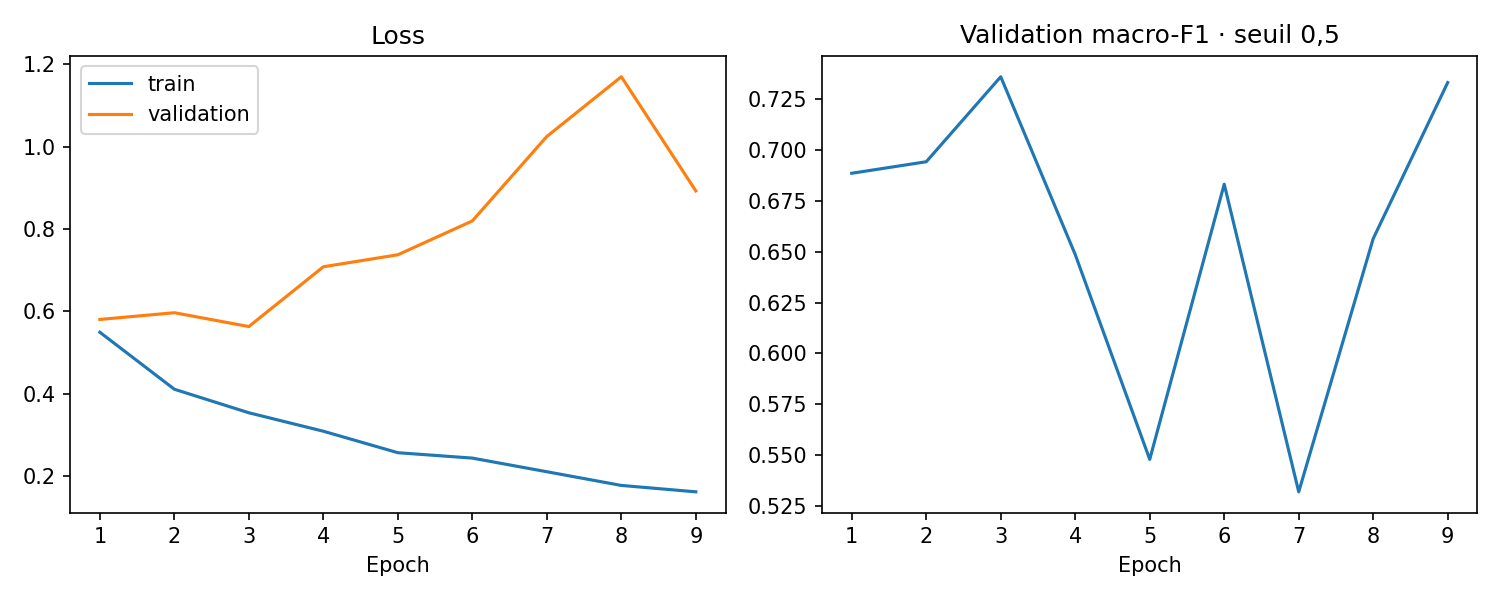

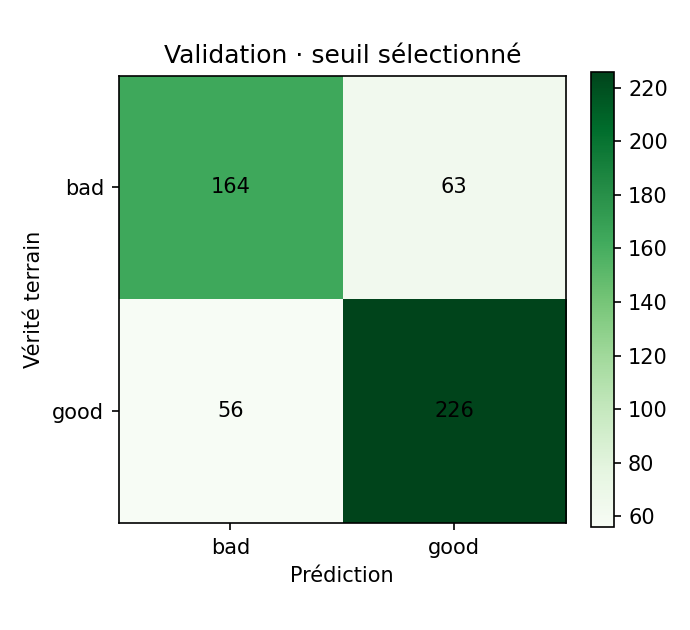

In [46]:
from IPython.display import Image, Markdown, display

REPORT = None
REPORT_PATH = None
if TRAIN_RESULT is not None:
    REPORT_PATH = PROJECT_ROOT / TRAIN_RESULT["report_paths"]["run"]
    REPORT = json.loads(REPORT_PATH.read_text(encoding="utf-8"))
    if REPORT["split"]["test_manifest_opened"] is not False:
        raise RuntimeError("Le rapport ne prouve pas la fermeture du test")
    display(Markdown(
        f"**Mode :** `{REPORT['mode']}`  \
"
        f"**Benchmark éligible :** `{REPORT['benchmark_eligible']}`  \
"
        f"**Meilleure époque :** `{REPORT['selection']['best_epoch']}`  \
"
        f"**Seuil choisi sur validation :** `{REPORT['selection']['threshold']:.4f}`"
    ))
    for artifact_name in ("learning_curves", "confusion_matrix"):
        artifact_path = PROJECT_ROOT / REPORT["artifacts"][artifact_name]["path"]
        if sha256_file(artifact_path) != REPORT["artifacts"][artifact_name]["sha256"]:
            raise RuntimeError(f"Hash graphique incorrect : {artifact_name}")
        display(Image(filename=str(artifact_path)))
else:
    print("Aucun entraînement dans ce mode ; pas de rapport train/validation à afficher.")

In [47]:
EXPORT_RESULT = None
if EXPORT_ONNX and REPORT is not None:
    checkpoint_record = REPORT["artifacts"]["checkpoint"]
    checkpoint_path = PROJECT_ROOT / checkpoint_record["path"]
    export_directory = PROJECT_ROOT / "data/experiments/ooc-cnn" / RUN_ID / "onnx"
    EXPORT_RESULT = run_cli([
        "export",
        "--config", str(CONFIG_RELATIVE_PATH),
        "--checkpoint", str(checkpoint_path),
        "--checkpoint-sha256", checkpoint_record["sha256"],
        "--selection-report", str(REPORT_PATH),
        "--selection-report-sha256", sha256_file(REPORT_PATH),
        "--output-directory", str(export_directory),
    ])
    export_report = json.loads((export_directory / "export-report.json").read_text(encoding="utf-8"))
    print(json.dumps(export_report["export"], indent=2, sort_keys=True))
else:
    print("Export ONNX ignoré.")

{
  "artifacts": {
    "labels": {
      "path": "data/experiments/ooc-cnn/kaggle-validation-campaign-v2/onnx/labels.json",
      "sha256": "ecb8fb702c5984c800c683287dc7e3bd17393a846529bd3c6082d773cadfaab1",
      "size_bytes": 222
    },
    "onnx": {
      "path": "data/experiments/ooc-cnn/kaggle-validation-campaign-v2/onnx/model.onnx",
      "sha256": "3c9bf61ef20baebe82a383176deb0e390ee02bc653745b106904226157e03586",
      "size_bytes": 6089247
    },
    "preprocessing": {
      "path": "data/experiments/ooc-cnn/kaggle-validation-campaign-v2/onnx/preprocessing.json",
      "sha256": "4b89e7d947e183d370e9c5ef255435f2a86eb9c93340a42deae1dccccd900b6d",
      "size_bytes": 457
    }
  },
  "benchmark_eligible_source": true,
  "checkpoint": {
    "path": "data/experiments/ooc-cnn/kaggle-validation-campaign-v2/best-checkpoint.pt",
    "sha256": "f55c53390101cba03cdf340e06c1d6b543e31284e5e2eacc38815581bf32e74d",
    "size_bytes": 6216789
  },
  "config_sha256": "134ee19c9983cc838be459fc0

## 6. Gel d'une validation

Le gel enregistre la configuration, le checkpoint, le seuil et les hashes du code. Il conserve seulement le chemin et le hash attendus du manifeste test, sans l'ouvrir.

In [48]:
FREEZE_RESULT = None
if RUN_MODE == "validation" and FREEZE_VALIDATION_SELECTION and REPORT is not None:
    checkpoint_record = REPORT["artifacts"]["checkpoint"]
    frozen_output = PROJECT_ROOT / "data/experiments/ooc-cnn" / RUN_ID / "frozen-selection.json"
    FREEZE_RESULT = run_cli([
        "freeze",
        "--config", str(CONFIG_RELATIVE_PATH),
        "--validation-report", str(REPORT_PATH),
        "--checkpoint", str(PROJECT_ROOT / checkpoint_record["path"]),
        "--output", str(frozen_output),
    ])
    print(json.dumps(FREEZE_RESULT, indent=2, ensure_ascii=False, sort_keys=True))
else:
    print("Gel ignoré : il ne concerne qu'une validation explicitement sélectionnée.")

{
  "frozen_manifest": "/kaggle/working/organchip-ooc-cnn/organchip-insight/data/experiments/ooc-cnn/kaggle-validation-campaign-v2/frozen-selection.json",
  "sha256": "852692b5d4ccc51573b0c94cb98f5c5603d4ed0f09ace2d38afbe803be5d6a9d",
  "test_manifest_opened": false
}

{
  "frozen_manifest": "/kaggle/working/organchip-ooc-cnn/organchip-insight/data/experiments/ooc-cnn/kaggle-validation-campaign-v2/frozen-selection.json",
  "sha256": "852692b5d4ccc51573b0c94cb98f5c5603d4ed0f09ace2d38afbe803be5d6a9d",
  "test_manifest_opened": false
}


## 7. Évaluation finale gelée — désactivée par défaut

Cette phase doit être lancée dans une exécution dédiée avec le bundle final local. Elle exige simultanément `RUN_MODE = "final-eval"`, `ENABLE_FINAL_EVAL = True`, le SHA-256 du manifeste gelé, une justification non vide et la confirmation exacte `OPEN_FROZEN_TEST_ONCE`. Après ces gardes, les artefacts non sensibles sont copiés vers le workspace. Le manifeste test reste dans l'entrée finale read-only : le CLI écrit un reçu local avant de l'ouvrir. Une seconde tentative est refusée tant que le workspace et son reçu sont conservés ; l'unicité globale repose sur l'archivage externe du reçu et la gouvernance du protocole.

In [49]:
FINAL_RESULT = None
if RUN_MODE == "final-eval":
    if ENABLE_FINAL_EVAL is not True:
        raise RuntimeError("Évaluation finale désactivée : décision humaine requise")
    if FINAL_EVAL_CONFIRMATION != EXPECTED_FINAL_EVAL_CONFIRMATION:
        raise RuntimeError("La confirmation finale exacte est absente")
    if not FINAL_EVAL_REASON.strip():
        raise RuntimeError("Une justification finale non vide est obligatoire")
    frozen_expected_sha256 = validate_sha256(FROZEN_MANIFEST_SHA256, "frozen manifest")
    if not FINAL_BUNDLE_ROOT.is_dir():
        raise FileNotFoundError(FINAL_BUNDLE_ROOT)

    final_staging = PROJECT_ROOT / "data/inputs/ooc-cnn/final"
    final_staging.mkdir(parents=True, exist_ok=True)
    frozen_manifest_path = final_staging / "frozen-selection.json"
    frozen_input_relative = FROZEN_MANIFEST_INPUT.relative_to(FINAL_BUNDLE_ROOT)
    frozen_manifest_source = checked_input_file(FINAL_BUNDLE_ROOT, frozen_input_relative)
    shutil.copy2(frozen_manifest_source, frozen_manifest_path)
    if sha256_file(frozen_manifest_path) != frozen_expected_sha256:
        raise ValueError("Le manifeste gelé ne correspond pas au SHA-256 autorisé")
    frozen = json.loads(frozen_manifest_path.read_text(encoding="utf-8"))

    # Les artefacts non sensibles déjà présents doivent être identiques ; les autres
    # sont copiés depuis le bundle final qui reproduit les chemins relatifs du projet.
    frozen_records = [
        record
        for artifact_name, record in frozen["artifacts"].items()
        if artifact_name != "test_manifest"
    ] + list(frozen["source_files"])
    for record in frozen_records:
        pure_path = PurePosixPath(record["path"])
        if pure_path.is_absolute() or any(part in {"", ".", ".."} for part in pure_path.parts):
            raise ValueError(f"Chemin gelé non sûr : {record['path']}")
        relative_path = Path(*pure_path.parts)
        destination = PROJECT_ROOT / relative_path
        if destination.is_file():
            if sha256_file(destination) != record["sha256"]:
                raise ValueError(f"Artefact actif différent du gel : {relative_path}")
        else:
            copy_verified_file(FINAL_BUNDLE_ROOT, relative_path, PROJECT_ROOT, record["sha256"])

    checkpoint_record = frozen["artifacts"]["checkpoint"]
    test_manifest_record = frozen["artifacts"]["test_manifest"]
    if test_manifest_record["sha256"] != SPLIT_LOCK.test.sha256:
        raise ValueError("Le hash test gelé ne correspond pas au split lock")
    FINAL_REQUIRED_HASHES = validate_required_hashes(
        contract_path=CONTRACT_PATH,
        expected_sha256=CONTRACT_SHA256,
        mode=RunMode.FINAL_EVAL,
        provided_hashes={
            **COMMON_REQUIRED_HASHES,
            "frozen_manifest_sha256": sha256_file(frozen_manifest_path),
            "checkpoint_sha256": checkpoint_record["sha256"],
            "test_manifest_sha256": test_manifest_record["sha256"],
        },
    )
    print(json.dumps({"validated_required_hashes": FINAL_REQUIRED_HASHES}, indent=2, sort_keys=True))

    if not FINAL_IMAGE_ROOT.is_dir() or FINAL_IMAGE_ROOT.is_symlink():
        raise ValueError("La racine d'images finale locale est absente ou non sûre")
    FINAL_IMAGE_ROOT.resolve().relative_to(Path("/kaggle/input").resolve())
    external_test_manifest = FINAL_BUNDLE_ROOT / TEST_MANIFEST_RELATIVE
    if external_test_manifest.is_symlink():
        raise ValueError("Le manifeste test externe ne doit pas être un symlink")
    external_test_manifest.resolve(strict=True).relative_to(FINAL_BUNDLE_ROOT.resolve())

    FINAL_RESULT = run_cli([
        "final-eval",
        "--config", str(CONFIG_RELATIVE_PATH),
        "--device", "cuda",
        "--image-root", str(FINAL_IMAGE_ROOT),
        "--test-manifest", str(external_test_manifest),
        "--test-manifest-root", str(FINAL_BUNDLE_ROOT),
        "--frozen-manifest", str(frozen_manifest_path),
        "--frozen-manifest-sha256", frozen_expected_sha256,
        "--confirm-test-open", FINAL_EVAL_CONFIRMATION,
        "--reason", FINAL_EVAL_REASON,
        "--run-id", RUN_ID,
    ])
    final_report_path = PROJECT_ROOT / FINAL_RESULT["report_paths"]["run"]
    final_report = json.loads(final_report_path.read_text(encoding="utf-8"))
    display(Markdown(f"**Évaluation finale gelée terminée.** Reçu : `{final_report['protocol']['test_access_receipt']}`"))
    display(Image(filename=str(PROJECT_ROOT / final_report["artifacts"]["confusion_matrix"]["path"])))
else:
    print("Évaluation finale non demandée ; aucun artefact test n'a été préparé ni ouvert.")

Évaluation finale non demandée ; aucun artefact test n'a été préparé ni ouvert.


## Sorties à conserver

Conserver le rapport JSON, l'instantané d'environnement, les prédictions, les graphiques, le checkpoint, le manifeste gelé éventuel et le dossier ONNX. Pour une évaluation finale, conserver aussi immédiatement `reports/test-access/ooc-cnn` hors du workspace : ce reçu local est la preuve de l'accès et le verrou d'une nouvelle tentative dans ce même workspace. Ces petits fichiers se trouvent sous `/kaggle/working/organchip-ooc-cnn/organchip-insight/data/experiments/ooc-cnn`, `reports/generated/ooc-cnn` et, le cas échéant, `reports/test-access/ooc-cnn`; les images restent sous `/kaggle/input`. Leur téléchargement manuel depuis l'interface Kaggle ne crée ni notebook, ni version de dataset, ni soumission.